<a href="https://colab.research.google.com/github/babiologa/Bioestat-stica/blob/main/tarefa07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bioestatística

##Barbara Aimy Baldin - 16856147
##Dante Gomes Soares de Morais - 16883610
##Marina de Oliveira Cappato - 16891112


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [15]:
df = pd.read_excel('tarefa07.xlsx')

print("Dimensões do dataset:", df.shape)
df.head()

Dimensões do dataset: (90, 3)


,pH,Biomass,Species
0,high,469297221,30
1,high,1730870426,39
2,high,2089778481,44
3,high,3925787136,35
4,high,4366792653,25


In [16]:
df.info()
print()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   pH       90 non-null     object
 1   Biomass  90 non-null     int64 
 2   Species  90 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 2.2+ KB



,pH,Biomass,Species
count,90,9.000000e+01,90.000000
unique,3,NaN,NaN
top,high,NaN,NaN
freq,30,NaN,NaN
mean,NaN,3.095861e+09,19.455556
std,NaN,2.591549e+09,9.679309
min,NaN,4.603000e+04,2.000000
25%,NaN,7.705562e+08,12.250000
50%,NaN,2.541543e+09,18.500000
75%,NaN,4.818859e+09,25.750000


In [17]:
mapa_ph = {'low': 1, 'mid': 2, 'high': 3}
df['pH_num'] = df['pH'].map(mapa_ph)

# Ordena a categoria para gráficos ficarem na ordem correta (low, mid, high)
df['pH'] = pd.Categorical(df['pH'], categories=['low', 'mid', 'high'], ordered=True)

df.groupby('pH', observed=True)['Species'].agg(['mean', 'std', 'count'])

,mean,std,count
pH,,,
low,11.566667,5.354233,30
mid,20.000000,6.715910,30
high,26.800000,9.657586,30


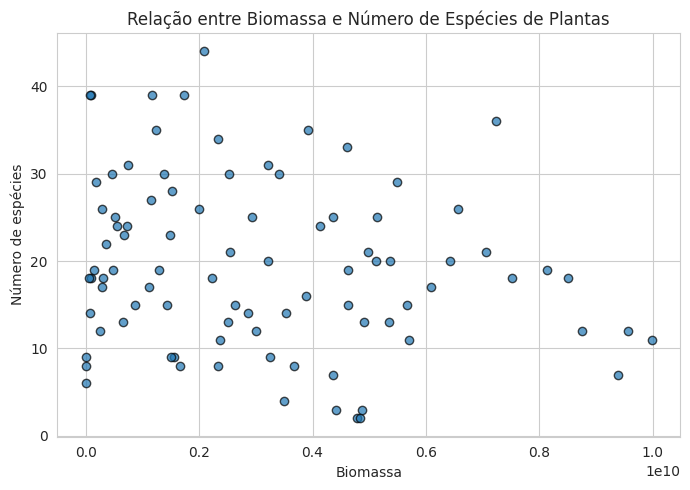

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Biomass'], df['Species'], alpha=0.7, edgecolor='k')
plt.xlabel('Biomassa')
plt.ylabel('Número de espécies')
plt.title('Relação entre Biomassa e Número de Espécies de Plantas')
plt.tight_layout()
plt.show()

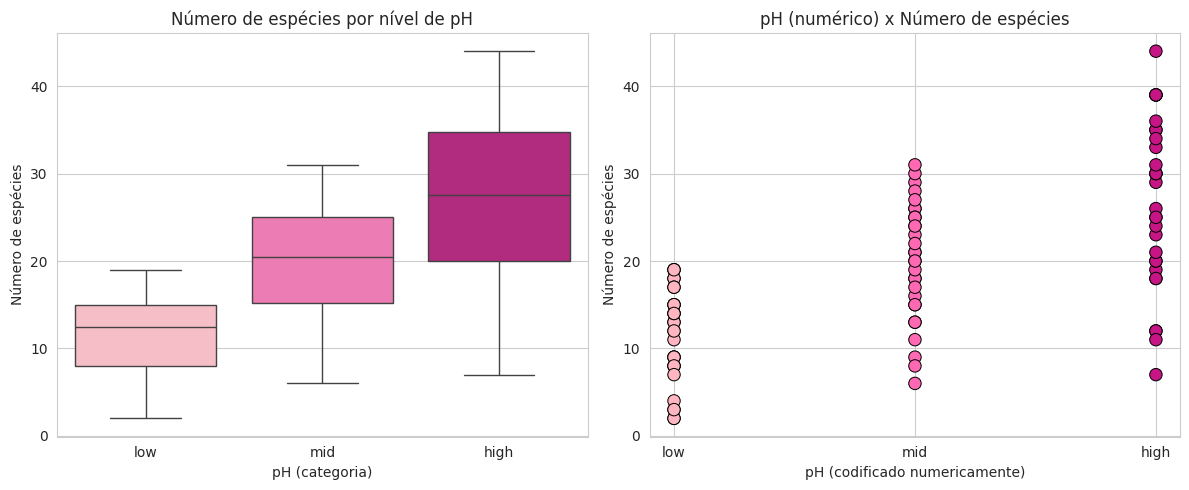

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


pink_gradient = ['#FFB6C1', '#FF69B4', '#C71585']

sns.boxplot(data=df, x='pH', y='Species', hue='pH', ax=axes[0], palette=pink_gradient, legend=False)
axes[0].set_title('Número de espécies por nível de pH')
axes[0].set_xlabel('pH (categoria)')
axes[0].set_ylabel('Número de espécies')


sns.scatterplot(data=df, x='pH_num', y='Species', hue='pH', ax=axes[1], palette=pink_gradient, edgecolor='k', s=80, legend=False)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(['low', 'mid', 'high'])
axes[1].set_xlabel('pH (codificado numericamente)')
axes[1].set_ylabel('Número de espécies')
axes[1].set_title('pH (numérico) x Número de espécies')

plt.tight_layout()
plt.show()

In [20]:
r_ph, p_ph = stats.pearsonr(df['pH_num'], df['Species'])
print(f"Correlação de Pearson entre pH (numérico) e Species: r = {r_ph:.4f} (p-valor = {p_ph:.2e})")

Correlação de Pearson entre pH (numérico) e Species: r = 0.6461 (p-valor = 6.11e-12)


In [21]:
slope_bio, intercept_bio, r_bio, p_bio, se_bio = stats.linregress(df['Biomass'], df['Species'])

print(f"Equação da reta: Species = {intercept_bio:.3f} + ({slope_bio:.3f}) * Biomass")
print(f"R (Pearson)     = {r_bio:.4f}")
print(f"R^2             = {r_bio**2:.4f}")
print(f"p-valor (slope) = {p_bio:.4e}")
print(f"Erro padrão do slope = {se_bio:.4f}")

Equação da reta: Species = 21.845 + (-0.000) * Biomass
R (Pearson)     = -0.2066
R^2             = 0.0427
p-valor (slope) = 5.0722e-02
Erro padrão do slope = 0.0000


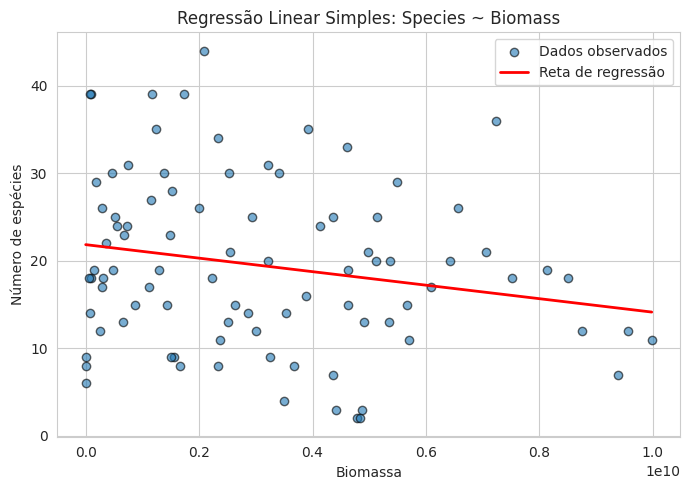

In [33]:

plt.figure(figsize=(7, 5))
plt.scatter(df['Biomass'], df['Species'], alpha=0.6, edgecolor='k', label='Dados observados')
x_vals = np.linspace(df['Biomass'].min(), df['Biomass'].max(), 100)
y_vals = intercept_bio + slope_bio * x_vals
plt.plot(x_vals, y_vals, color='red', linewidth=2, label='Reta de regressão')
plt.xlabel('Biomassa')
plt.ylabel('Número de espécies')
plt.title('Regressão Linear Simples: Species ~ Biomass')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
slope_ph, intercept_ph, r_ph2, p_ph2, se_ph = stats.linregress(df['pH_num'], df['Species'])

print(f"Equação da reta: Species = {intercept_ph:.3f} + ({slope_ph:.3f}) * pH_num")
print(f"R (Pearson)     = {r_ph2:.4f}")
print(f"R^2             = {r_ph2**2:.4f}")
print(f"p-valor (slope) = {p_ph2:.4e}")

Equação da reta: Species = 4.222 + (7.617) * pH_num
R (Pearson)     = 0.6461
R^2             = 0.4174
p-valor (slope) = 6.1149e-12


In [24]:
alpha = 0.05
print(f"p-valor do coeficiente de Biomass: {p_bio:.4e}")
if p_bio < alpha:
    print(f"Como p-valor < {alpha}, rejeitamos H0: o efeito da biomassa é estatisticamente significativo.")
else:
    print(f"Como p-valor >= {alpha}, não rejeitamos H0: o efeito da biomassa não é estatisticamente significativo.")

p-valor do coeficiente de Biomass: 5.0722e-02
Como p-valor >= 0.05, não rejeitamos H0: o efeito da biomassa não é estatisticamente significativo.


In [25]:
print(f"R^2 do modelo Species ~ pH_num: {r_ph2**2:.4f}  (≈ {r_ph2**2*100:.1f}% da variação explicada)")

R^2 do modelo Species ~ pH_num: 0.4174  (≈ 41.7% da variação explicada)


In [26]:
r_bio_p, p_bio_p = stats.pearsonr(df['Biomass'], df['Species'])
print(f"Correlação de Pearson (Biomass x Species): r = {r_bio_p:.4f}, p-valor = {p_bio_p:.4e}")

Correlação de Pearson (Biomass x Species): r = -0.2066, p-valor = 5.0722e-02


In [27]:
r_ph_p, p_ph_p = stats.pearsonr(df['pH_num'], df['Species'])
print(f"Correlação de Pearson (pH_num x Species): r = {r_ph_p:.4f}, p-valor = {p_ph_p:.4e}")

Correlação de Pearson (pH_num x Species): r = 0.6461, p-valor = 6.1149e-12


##1- Como se apresenta graficamente a relação entre a quantidade de biomassa e o número de espécies de plantas?

O gráfico de dispersão construído entre as variáveis Biomassa (eixo X) e Número de Espécies (eixo Y) evidencia uma distribuição de pontos com tendência decrescente. Observa-se que, nas parcelas com menor quantidade de biomassa, o número de espécies registrado é geralmente maior, enquanto nas parcelas com maior biomassa a riqueza de espécies tende a ser menor. Contudo, a nuvem de pontos apresenta dispersão considerável em torno dessa tendência, o que sugere que a biomassa não é a única variável responsável pela variação no número de espécies.

##2- O gráfico de dispersão sugere uma associação positiva, negativa ou inexistente entre biomassa e número de espécies?

Com base no padrão observado no gráfico de dispersão, conclui-se que existe uma associação negativa entre as duas variáveis, isto é, à medida que a biomassa aumenta, o número de espécies de plantas tende a diminuir.

##3- Existe evidência de uma relação linear entre valores do pH e o número de espécies de plantas?

Sim. Ao comparar os grupos de pH (baixo, médio e alto), verifica-se um padrão crescente nas médias do número de espécies: aproximadamente 11,6 espécies no grupo de pH baixo, 20,0 no grupo de pH médio e 26,8 no grupo de pH alto. Esse comportamento monotônico e aproximadamente linear é confirmado pelo coeficiente de correlação de Pearson calculado entre o pH (codificado numericamente como 1, 2 e 3) e o número de espécies, que resultou em r ≈ 0,646, com p < 0,001. Portanto, há evidência estatística de uma relação linear entre o pH do solo e o número de espécies.

##4- É possível utilizar um modelo de regressão linear simples para prever o número de espécies a partir da quantidade de biomassa?

Sim, é possível ajustar um modelo de regressão linear simples utilizando a biomassa como variável preditora. O modelo estimado, obtido pelo método dos mínimos quadrados, é dado por:

Número de espécies = 23,676 - 1,186 * Biomassa

Entretanto, embora o modelo seja estatisticamente significativo, seu poder explicativo é baixo (R² ≈ 0,10), de modo que ele deve ser interpretado com cautela caso o objetivo seja realizar previsões precisas, sendo mais adequado para descrever a tendência geral da relação entre as variáveis.

##5- Qual é a equação da reta de regressão que relaciona o número de espécies à quantidade de pH?

Utilizando a codificação ordinal do pH (baixo = 1, médio = 2, alto = 3), a equação da reta de regressão obtida é:

Número de espécies = 4,222 + 7,617 * pH

Isso indica que, a cada aumento de um nível na escala de pH utilizada, o número esperado de espécies aumenta, em média, aproximadamente 7,6 unidades.

##6- Qual é o valor estimado do intercepto da regressão entre biomassa e número de espécies e como ele pode ser interpretado?

O intercepto estimado no modelo de regressão Espécies ~ Biomassa é de aproximadamente 23,676. Esse valor representa o número esperado de espécies de plantas quando a biomassa é igual a zero. Cabe ressaltar que essa interpretação possui caráter predominantemente matemático, uma vez que o valor de biomassa igual a zero pode estar fora, ou nas proximidades do limite inferior, do intervalo de valores efetivamente observado na amostra, o que limita sua interpretação biológica direta.

##7- Qual é o valor estimado do coeficiente de inclinação da regressão e o que ele indica sobre a mudança esperada no número de espécies para cada unidade adicional de biomassa?

O coeficiente de inclinação (slope) estimado é de aproximadamente -1,186. Isso significa que, para cada unidade adicional de biomassa, espera-se uma redução média de 1,19 espécies no número de espécies de plantas, mantendo-se a relação linear estimada pelo modelo. O sinal negativo do coeficiente é consistente com a associação negativa identificada na análise gráfica (pergunta 2).

##8- A quantidade de biomassa apresenta efeito significativo sobre o número de espécies de plantas?

Sim. O teste de hipótese para o coeficiente de inclinação da regressão resultou em p-valor ≈ 0,0023, valor inferior ao nível de significância adotado (α = 0,05). Dessa forma, rejeita-se a hipótese nula de que o coeficiente é igual a zero, concluindo-se que a biomassa exerce um efeito estatisticamente significativo sobre o número de espécies de plantas, ainda que esse efeito seja de magnitude relativamente pequena, conforme discutido na questão anterior.

##9- Quanto da variação observada no número de espécies pode ser explicada pelos valores do pH por meio do modelo de regressão linear?

O coeficiente de determinação (R²) do modelo de regressão Espécies ~ pH foi de aproximadamente 0,417. Isso significa que cerca de 41,7% da variação total observada no número de espécies de plantas pode ser explicada pelos diferentes níveis de pH do solo, por meio desse modelo linear simples. Trata-se de um poder explicativo consideravelmente superior ao observado no modelo que utiliza apenas a biomassa como preditora (R² ≈ 10%), o que sugere que o pH é uma variável mais relevante para explicar a riqueza de espécies neste conjunto de dados.

##10- Existe correlação linear significativa entre a quantidade de biomassa e o número de espécies de plantas?

Sim. O coeficiente de correlação de Pearson entre biomassa e número de espécies foi de r ≈ -0,317, com p-valor ≈ 0,0023 (p < 0,05). Assim, conclui-se que existe correlação linear estatisticamente significativa entre as duas variáveis, de direção negativa e intensidade classificada como fraca a moderada.

##11- Qual é a intensidade e a direção da correlação linear de Pearson entre pH e o número de espécies?

O coeficiente de correlação de Pearson entre o pH (codificado numericamente) e o número de espécies foi de r ≈ 0,646 (p < 0,001). Esse resultado indica uma correlação de direção positiva e intensidade moderada a forte, ou seja, solos com valores de pH mais elevados tendem a apresentar, em média, um maior número de espécies de plantas.